# HCP engagement: exploratory data review

These tables record the data review preceding the initial model. The current [findings](../reports/comparison/findings.md) and [methodology](../docs/analysis_guide.md) incorporate the subsequent model comparisons and targeted checks.

## Main observations

Strict response contains **3,424 positive HCP-months (7.05%)**. All strict positives are also loose positives. Availability and extraction changes limit what historical performance can establish.

- Logged visits, samples and formulary coverage change from July 2025.
- Prescribing measurements and visit recency change again in scoring. Two measurements are exact mappings of decile, with different mappings in each file.
- The follow-up flag is **87.77% missing** in scoring and strongly associated with response in training. The downstream flags require an availability audit before predictive use.
- **18.22% of scoring rows** belong to HCPs absent from training. Ordinary temporal evaluation cannot measure that cohort here.


## Context and methods

The decision is whether an HCP ranking merits further investment. The supplied training, scoring and submission CSVs are under `data/raw/`; definitions come from the original [brief](../docs/source/Candidate_Brief.docx) and [dictionary](../docs/source/Data_Dictionary.xlsx).

These are descriptive checks of all supplied rows. Scoring has no labels. Recent training (July–December 2025) is the main distribution reference; full-history comparisons are labelled separately. KS distances describe separation among observed values, with missingness shown separately; no independence-based p-values are interpreted.

One row is one HCP-month. The temporal design assumes predictions at the start of a month, an outcome in the next calendar month and availability at the end of the outcome month. The documents do not establish those exact cutoffs. Contact capacity is a scenario, and observational response is not causal engagement uplift.

To regenerate this notebook, install `requirements-notebook.txt` and run `python scripts/run_notebook.py` from the repository root. Saved outputs contain a completed sequential execution of all eight code cells. `python -m src.eda` regenerates the evidence tables and figures.


### Load the supplied extracts and run structural checks

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data/raw").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.eda import load_data, build_tables, make_figures

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 10)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
train, score, template = load_data(ROOT)
tables = build_tables(train, score, template)  # includes schema and key assertions
print("Structural, range, target-nesting and submission-alignment checks passed.")

Structural, range, target-nesting and submission-alignment checks passed.


## Data

### Confirm grain, dates and population coverage

In [2]:
display(tables["structure"])
display(tables["score_cohorts"])

,dataset,rows,hcps,first_period,last_period,duplicate_hcp_months,missing_cells,min_rows_per_hcp,median_rows_per_hcp,max_rows_per_hcp
0,train,48585,2100,2024-01,2025-12,0,0,19,23.0000,24
1,score,12723,2200,2026-01,2026-06,0,11167,3,6.0000,6


,cohort,rows,hcps,row_share
0,new in score,2318,400,0.1822
1,seen in train,10405,1800,0.8178


The 12,723 submission IDs match scoring in order. All missing cells belong to the follow-up flag. HCPs repeat over months; row counts are not counts of independent people.

## Results

### Compare the outcome definitions


,target,rows,positives,prevalence
0,responded_strict,48585,3424,0.0705
1,responded_loose,48585,13186,0.2714


,responded_strict,responded_loose,rows
0,0,0,35399
1,0,1,9762
2,1,1,3424


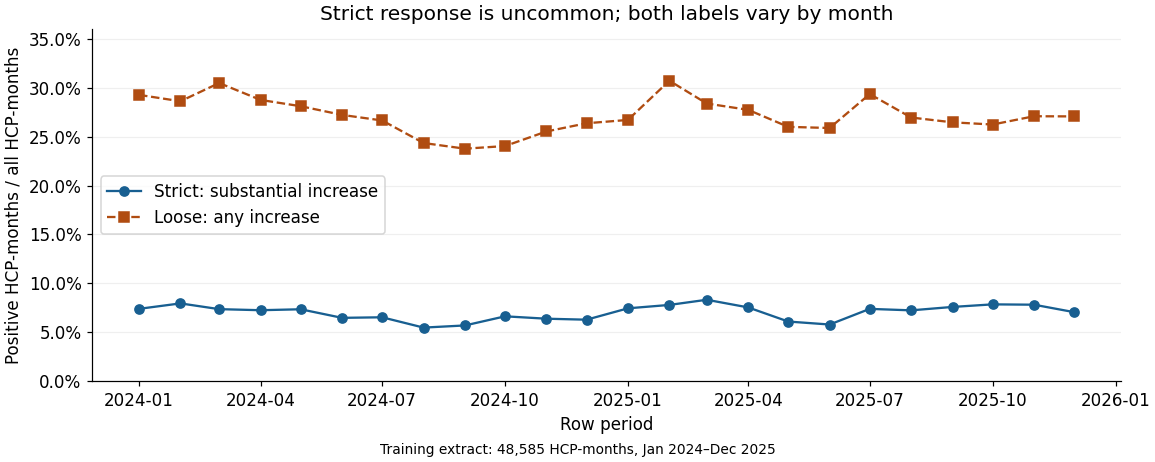

In [3]:
display(tables["targets"])
display(tables["target_overlap"])
figures = make_figures(tables)
display(figures["target_rates"])
plt.close(figures["target_rates"])

Strict response is the starting target because its stated definition requires a substantial increase. There are 451 and 460 positives in the two proposed evaluation windows. Loose response remains a sensitivity; the numerical label construction remains unspecified.

### Locate distribution changes in time

,phase,rows,strict_rate,loose_rate,calls_mean,samples_mean,preferred_share,followup_missing_rate
0,2024-01 to 2025-06,36450,0.0689,0.2713,4.3076,3.8769,0.2233,0.0000
1,2025-07 to 2025-12,12135,0.0751,0.2718,3.1158,2.7744,0.4079,0.0000
2,2026-01 to 2026-06,12723,NaN,NaN,3.0865,2.7835,0.4096,0.8777


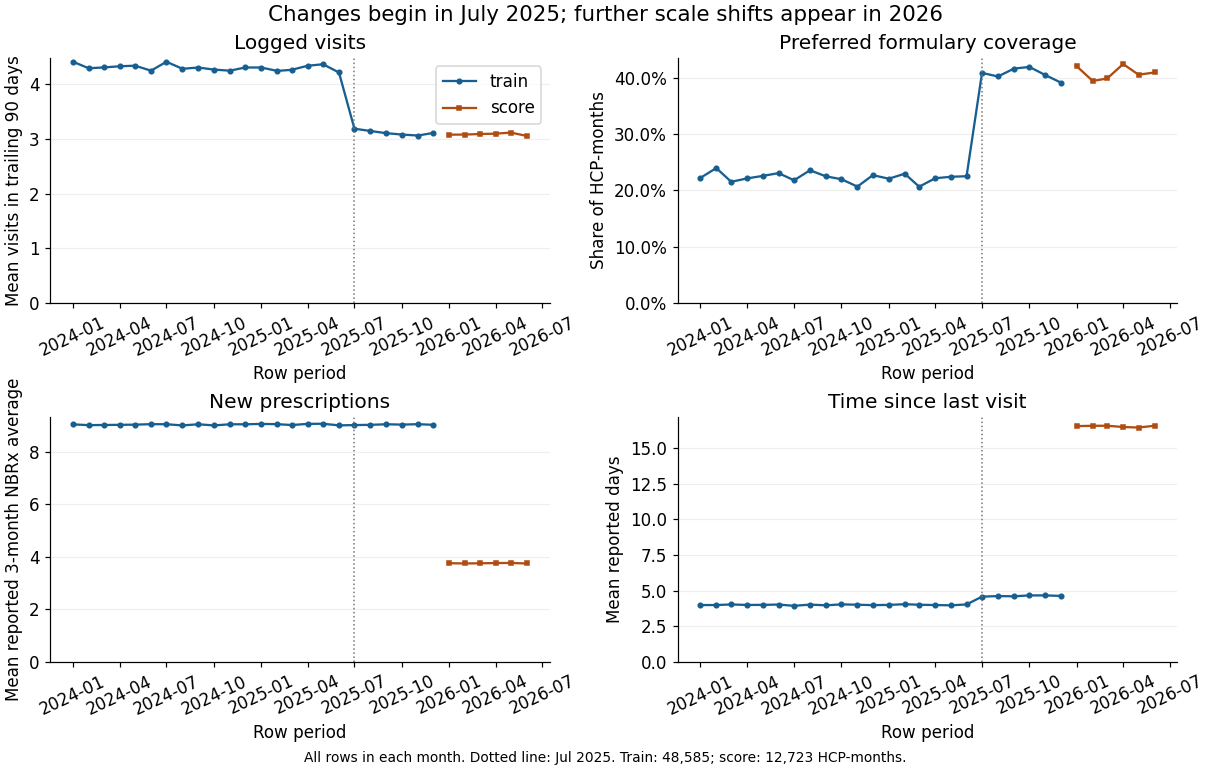

In [4]:
display(tables["phases"])
display(figures["monthly_changes"])
plt.close(figures["monthly_changes"])

The change in visits and preferred coverage starts within training, in July 2025, and persists into scoring. Prescribing scales and visit recency change at the 2026 boundary. These are separate issues: comparison with recent training addresses the first and still reveals the second.

### Check whether the shift remains for the same HCPs

In [5]:
display(tables["paired_shift"])
display(tables["decile_mapping"].query("decile == 6"))
assert tables["decile_mapping"]["patient_values"].eq(1).all()
assert tables["decile_mapping"]["nbrx_values"].eq(1).all()

,feature,hcp_pairs,nonzero_denominators,ratio_p10,ratio_median,ratio_p90
0,patient_volume_est,1676,1676,1.1163,1.1240,1.1271
1,nbrx_3m_avg,1676,1676,0.4165,0.4176,0.4183
2,nbrx_last_month,1676,1676,0.2275,0.4208,0.7608
3,trx_3m_avg,1676,1676,0.2815,0.4139,0.6189
4,days_since_last_call,1676,1676,2.2000,3.6000,5.6000
5,calls_last_90d,1676,1513,0.2000,1.0000,3.0000
6,samples_dropped_last_90d,1676,1302,0.0000,0.9375,3.0000


,dataset,decile,rows,patient_values,patient_value,nbrx_values,nbrx_value
5,score,6,1288,1,133.0000,1,4.0200
15,train,6,4834,1,118.0000,1,9.6200


Among 1,676 December–January HCP pairs, the median NBRx-average ratio is 0.418. Both NBRx average and patient volume are deterministic mappings of decile in each extract; all ten deciles pass the checks. The mappings differ between extracts. The model excludes these measures; no unit conversion is inferred.

### Separate descriptive signal from available predictors

,followup_call_logged_flag,territory_target_refresh_flag,rows,strict_positives,strict_rate,loose_rate
0,0.0000,0.0000,31149,235,0.0075,0.2234
1,0.0000,1.0000,9983,318,0.0319,0.2368
2,1.0000,0.0000,4680,1183,0.2528,0.4158
3,1.0000,1.0000,2773,1688,0.6087,0.6917


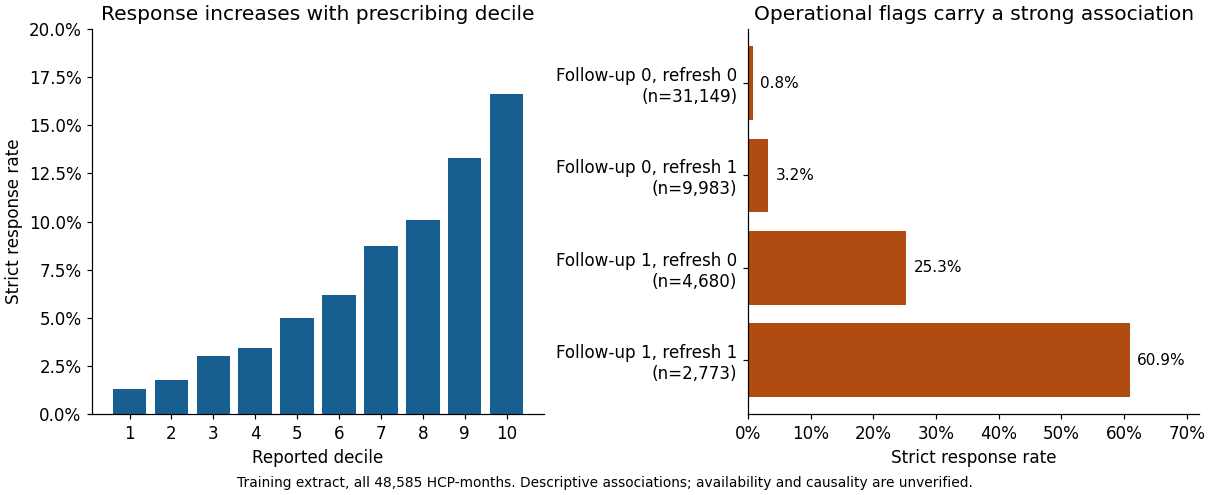

In [6]:
display(tables["flag_associations"])
display(figures["response_associations"])
plt.close(figures["response_associations"])

The flags have a large association with the outcome, including within both historical phases. Combined with the dictionary warning and missing scoring follow-ups, this prevents using them in the main model without an availability audit. It does not by itself prove leakage or a causal relationship.

### Check definitions and categorical coverage

In [7]:
display(tables["semantic_checks"])
display(tables["category_shift"][["feature", "train_categories", "score_categories", "unseen_score_rows"]])

,dataset,rows,zero_visits_recent_call
0,score,12723,1298
1,train,48585,3194


,feature,train_categories,score_categories,unseen_score_rows
0,specialty,5,5,0
1,region,5,5,0
2,territory_id,347,348,24
3,institution_type,4,4,0
4,campaign_wave_id,219,219,0
5,formulary_status,4,4,0


A zero visit count together with a visit within 90 days conflicts under the literal definitions: 3,194 training rows and 1,298 scoring rows have this combination. The raw values remain unchanged; the logging rules require reconciliation. Territory is the only categorical feature with unseen scoring values; 24 rows are affected.

### Set temporal windows with an explicit label-availability assumption

In [8]:
display(tables["proposed_windows"])

,window,fit_through,evaluate_from,evaluate_through,fitting_rows,evaluation_rows,strict_positives,loose_positives,unseen_hcp_rows
0,development,2025-05,2025-07,2025-09,34436,6075,451,1675,0
1,later_check,2025-08,2025-10,2025-12,40487,6060,460,1623,0


## Implications for the ranking analysis

The observations support a temporal benchmark with an explicit label-availability gap and training-only preprocessing. They also identify fields whose timing or construction prevents straightforward predictive use. The [feature matrix](../docs/methodology/feature_decisions.md) records the eligibility decisions, and the [methodology](../docs/analysis_guide.md) defines the comparisons, capacities and sensitivity checks.

All training HCPs appear before the evaluation windows. A group-withholding stress check can explore unfamiliar HCPs, but cannot establish performance on actual 2026 newcomers. Aggregate labels from both windows were reviewed during exploration, so the later period is not an untouched holdout.

The EDA does not establish incremental commercial return or production calibration. The [investment recommendation](../reports/comparison/findings.md) combines these observations with the model and policy evidence.
